Projeto Transfer Learning \
Descidi fazer meu próprio dataset com imagem online. Descidi usar as  classes gato e coelho para que eu possa testar o modelo com meu pet (coelho)   

Imports

In [1]:
%matplotlib inline

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import keras

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
!rm -rf Dataset-bunny_cat/
!git clone https://github.com/AllJordanSS/Atividades_bootcamp_BairesDev.git -b At.2-Transfer_Learning

!pip install seaborn

Cloning into 'Atividades_bootcamp_BairesDev'...
remote: Enumerating objects: 519, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 519 (delta 2), reused 10 (delta 1), pack-reused 501 (from 1)
Receiving objects: 100% (519/519), 135.20 MiB | 23.28 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (493/493), done.


Dataset Load

function to load, normalize image and imput vector

In [3]:
# helper function to load image and return it and input vector
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

In [4]:
root = 'Atividades_bootcamp_BairesDev/classes'
train_split, val_split = 0.7, 0.15

# Obter nomes das classes (sem o caminho completo)
categories = [os.path.basename(x[0]) for x in os.walk(root)][1:]
print("categorias: ", categories)

# Contar classes
num_classes = len(categories)

# Carregar dados
data = []

for c, category in enumerate(categories):
    # CORREÇÃO: Montar o caminho completo
    category_path = os.path.join(root, category)

    # Verificar se a pasta existe
    if not os.path.exists(category_path):
        print(f"Pasta não encontrada: {category_path}")
        continue

    # Listar todas as imagens na pasta
    images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(category_path)
              for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg', '.jpeg', '.png']]

    print(f"{category}: {len(images)} imagens encontradas")  # Debug: quantas imagens por classe

    for img_path in images:
        try:
            img, x = get_image(img_path)
            data.append({'x': np.array(x[0]), 'y': c})
        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")

categorias:  ['cat', 'bunny']
cat: 249 imagens encontradas
bunny: 239 imagens encontradas


Randomize the data order.

In [5]:
random.shuffle(data)

In [6]:
# Dividir em treino, validação e teste
idx_val = int(train_split * len(data))
idx_test = int((train_split + val_split) * len(data))

train = data[:idx_val]
val = data[idx_val:idx_test]
test = data[idx_test:]

# Extrair x e y
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]

# Verificar se y_test está vazio
print("Total de amostras:", len(data))
print("Treino:", len(train), "Validação:", len(val), "Teste:", len(test))
print("y_test:", y_test)  # Agora deve mostrar algo como [0, 1, 0, ...]

Total de amostras: 488
Treino: 341 Validação: 73 Teste: 74
y_test: [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]


Pre-process the data as before by making sure it's float32 and normalized between 0 and 1.

In [7]:
# normalize data
x_train = x_train.astype('float32') / 255.
x_val = x_val.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# convert labels to one-hot vectors
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test.shape)

(74, 2)


Let's get a summary of what we have.

In [8]:
# summary
print("finished loading %d images from %d categories"%(len(data), num_classes))
print("train / validation / test split: %d, %d, %d"%(len(x_train), len(x_val), len(x_test)))
print("training data shape: ", x_train.shape)
print("training labels shape: ", y_train.shape)

finished loading 488 images from 2 categories
train / validation / test split: 341, 73, 74
training data shape:  (341, 224, 224, 3)
training labels shape:  (341, 2)


Looking some images from Dataset

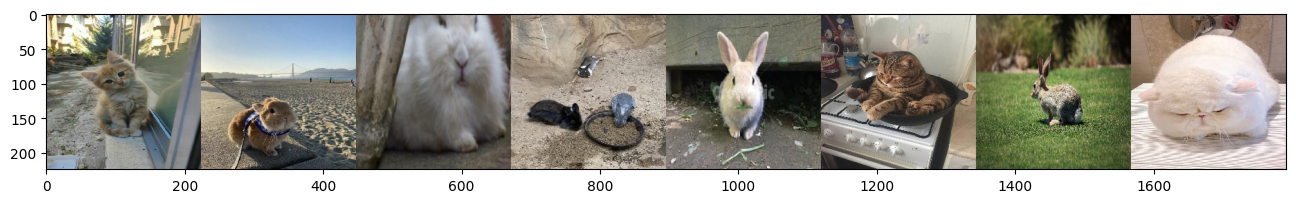

In [9]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

Tranfer Learning from Keras VGG16 trained with ImageNet Dataset


In [10]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Create a new classification layer

In [11]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model = Model(inp, out)

freeze weights for all layers except the new classification layer

In [12]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model.layers[-1:]):
    layer.trainable = True

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

training

In [13]:
history = model.fit(x_train, y_train,
                         batch_size=128,
                         epochs=5,
                         validation_data=(x_val, y_val))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 296s 105s/step - accuracy: 0.5462 - loss: 0.9598 - val_accuracy: 0.5616 - val_loss: 0.6797
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 316s 106s/step - accuracy: 0.5154 - loss: 0.8010 - val_accuracy: 0.6164 - val_loss: 0.6348
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 319s 105s/step - accuracy: 0.5740 - loss: 0.6704 - val_accuracy: 0.3699 - val_loss: 0.8874
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 326s 106s/step - accuracy: 0.5833 - loss: 0.6701 - val_accuracy: 0.6301 - val_loss: 0.6150
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 247s 85s/step - accuracy: 0.6063 - loss: 0.6202 - val_accuracy: 0.7260 - val_loss: 0.5924


Plot validation loss/accuracy

In [14]:
# Fazer previsões no conjunto de teste
y_pred_probs = model.predict(x_test)  # Probabilidades para cada classe
y_pred = np.argmax(y_pred_probs, axis=1)  # Classes previstas (0 ou 1)
y_true = np.argmax(y_test, axis=1)       # Classes reais (convertidas de one-hot)

3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step


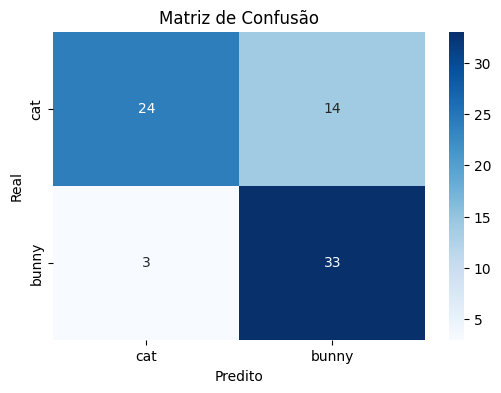

In [15]:
# Matriz de confusão

# Gerar matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Plotar matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [16]:
# Assumindo que "gato" é a classe positiva (índice 1)
# Extraímos os valores da matriz de confusão
tn, fp, fn, tp = cm.ravel()  # Ordem: TN, FP, FN, TP

print(f"Verdadeiros Positivos (VP): {tp}")
print(f"Verdadeiros Negativos (VN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")

Verdadeiros Positivos (VP): 33
Verdadeiros Negativos (VN): 24
Falsos Positivos (FP): 14
Falsos Negativos (FN): 3


In [17]:
# Cálculo das métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # também chamado de recall ou TPR
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print("\nMétricas de Classificação:")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Sensibilidade (Recall): {sensitivity:.4f}")
print(f"Especificidade: {specificity:.4f}")
print(f"F-Score (F1): {f1_score:.4f}")


Métricas de Classificação:
Acurácia: 0.7703
Precisão: 0.7021
Sensibilidade (Recall): 0.9167
Especificidade: 0.6316
F-Score (F1): 0.7952


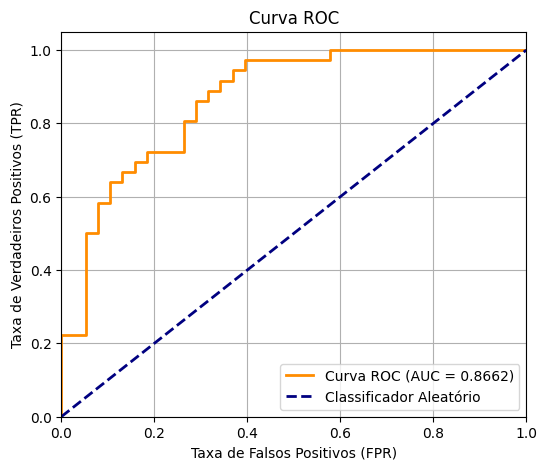

AUC (Área sob a curva ROC): 0.8662


In [18]:
# Calcular ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs[:, 1])  # usa probabilidade da classe positiva (gato)
roc_auc = auc(fpr, tpr)

# Plotar ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC (Área sob a curva ROC): {roc_auc:.4f}")

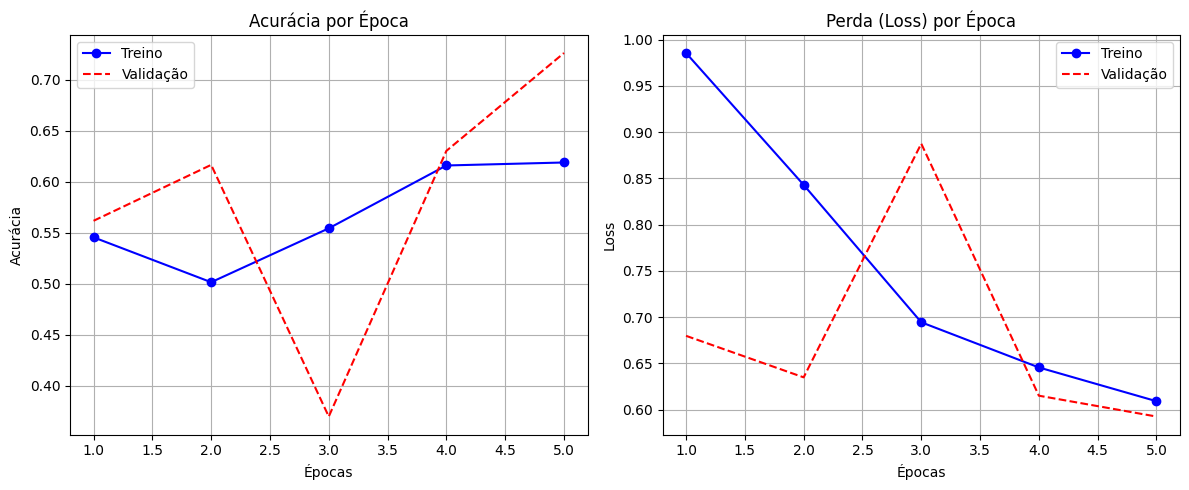

In [19]:
# --- GRÁFICO 1: Histórico de Treinamento (Loss e Accuracy) ---
import matplotlib.pyplot as plt

# 'history' vem do model.fit()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Subplot 1: Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Treino')
plt.plot(epochs, val_acc, 'r--', label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
# ➤ Análise: Se a acurácia de validação cresce junto com a do treino, o modelo está aprendendo bem.
#           Se divergir (val_acc cai enquanto train_acc sobe), há overfitting.

# Subplot 2: Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Treino')
plt.plot(epochs, val_loss, 'r--', label='Validação')
plt.title('Perda (Loss) por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# ➤ Análise: Loss deve diminuir. Se val_loss começar a subir, é overfitting.
#           Boa convergência = ambas as curvas estabilizam juntas.

plt.tight_layout()
plt.show()

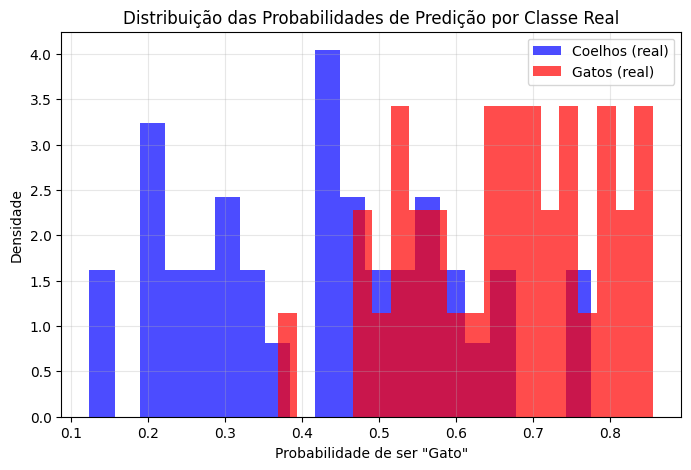

In [22]:
# --- GRÁFICO 4: Histograma das Probabilidades de Predição ---
plt.figure(figsize=(8, 5))

# Probabilidades da classe positiva (gato)
probs_positive = y_pred_probs[:, 1]

# Separa por verdadeiro positivo e verdadeiro negativo
true_cats = probs_positive[y_true == 1]   # verdadeiros gatos
true_bunnies = probs_positive[y_true == 0]  # verdadeiros coelhos

plt.hist(true_bunnies, bins=20, alpha=0.7, label='Coelhos (real)', color='blue', density=True)
plt.hist(true_cats, bins=20, alpha=0.7, label='Gatos (real)', color='red', density=True)
plt.xlabel('Probabilidade de ser "Gato"')
plt.ylabel('Densidade')
plt.title('Distribuição das Probabilidades de Predição por Classe Real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ➤ Análise: Um bom modelo separa bem as distribuições.
#           Gatos (vermelho) devem ter alta probabilidade → perto de 1.
#           Coelhos (azul) devem ter baixa probabilidade → perto de 0.
#           Sobreposição = confusão entre classes.

In [23]:
# --- GRÁFICO 5: Visualização de Imagens com Previsão ---
import matplotlib.pyplot as plt

def plot_sample_images(images, true_labels, pred_labels, pred_probs, num_samples=6):
    plt.figure(figsize=(15, 10))
    indices = np.random.choice(range(len(images)), num_samples, replace=False)

    for i, idx in enumerate(indices):
        img = images[idx]
        true_label = categories[true_labels[idx]]
        pred_label = categories[pred_labels[idx]]
        confidence = np.max(pred_probs[idx])

        plt.subplot(2, 3, i + 1)
        plt.imshow(img.astype('uint8'))  # volta ao formato original
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Verdadeiro: {true_label}\nPrevisto: {pred_label} ({confidence:.2f})", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Carregar imagens originais (sem preprocessamento) para visualização
x_test_original = np.array([t["x"] for t in test])  # já está em formato de imagem

plot_sample_images(x_test_original, y_true, y_pred, y_pred_probs, num_samples=6)

# ➤ Análise: Mostra como o modelo se comporta em exemplos reais.
#           Verde = acerto, Vermelho = erro.
#           Útil para identificar padrões de falha (ex: orelhas longas confundidas? fundo parecido?).

Output hidden; open in https://colab.research.google.com to view.

In [24]:
# --- GRÁFICO 6: Relatório de Classificação (Texto Estruturado) ---
from sklearn.metrics import classification_report

print("Relatório de Classificação:\n")
print(classification_report(y_true, y_pred, target_names=categories))

# ➤ Análise: Mostra precisão, recall (sensibilidade), f1-score e suporte para cada classe.
#           Ajuda a ver se o modelo é mais preciso em uma classe do que na outra.
#           F1-score equilibra precisão e recall.

Relatório de Classificação:

              precision    recall  f1-score   support

         cat       0.89      0.63      0.74        38
       bunny       0.70      0.92      0.80        36

    accuracy                           0.77        74
   macro avg       0.80      0.77      0.77        74
weighted avg       0.80      0.77      0.77        74

